# S&P 500 Options: Label Engineering

The label is the return on a short straddle - one call option and one put option on the
same stock, at the same strike price and the same expiration date, both sold at the same
moment. An option position is not a share position: the contract sold at entry has to be
the contract bought back at exit, and it stops existing on a date fixed when it is sold.
This notebook writes that convention down as a formula, checks that each labelled trade
has a price at both ends, measures how much independent information overlapping trades
carry, measures what one simple signal earns before any feature work, and writes the
label files the modelling stages train on.

## Learning objectives

- Build a forward return for an option position by pricing the same contract at entry and
  at exit, instead of shifting a price column
- Check that every labelled trade has a quoted price at both ends, and account for every
  row that has no label by the reason it has none
- Exclude the holdout period on the date a position settles rather than the date its
  signal is observed, where each contract fixes its own settlement date
- Measure how much independent evidence a label carries when trades opened on consecutive
  days stay open together for weeks
- Measure what one simple signal earns against the label before any feature work, with a
  standard error that allows for that overlap

## Book reference, prerequisites and artifacts

Chapter 7, Section 7.2. Reads the daily matched-strike straddle panel and the raw option
chain through `load_sp500_options_straddles()` and `load_sp500_options_straddles_raw()`,
whose coverage [`01_feasibility_analysis`](01_feasibility_analysis.ipynb) establishes,
the underlying closes through `load_sp500_daily_bars()`, and `config/setup.yaml`, which
declares the label set, the cross-validation buffer and the holdout boundary.

Writes five label files - `labels/ret_to_expiry.parquet`, `labels/fwd_ret_5d.parquet`,
`labels/fwd_ret_10d.parquet`, `labels/fwd_ret_dh_5d.parquet` and
`labels/fwd_ret_dh_10d.parquet` - each with a sidecar recording what it was built from.
`04_model_based_features.py` and `05_evaluation.py` read the primary label, and the model
and backtest stages load it through `utils/modeling.py` and
`case_studies/utils/backtest_loaders.py`. `05_evaluation.py` and `90_ic_diagnostic.py`
read `fwd_ret_dh_10d`, and `90_ic_diagnostic.py` also reads `fwd_ret_10d`. The two
intermediate frames the labels are built from, `labels/contract_returns.parquet` and
`labels/hedge_path.parquet`, are produced by `_label_artifacts.py`, which exists because
the round trip below is not a shift.

In [1]:
"""S&P 500 Options: Label Engineering."""

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.sp500_options._label_artifacts import accrued_hedge_pnl, ensure_label_artifacts
from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.label_diagnostics import effective_sample_size, panel_autocorrelation
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.artifact_specs import resolve_label_horizon
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

CASE_STUDY_ID = "sp500_options"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
LABELS_DIR = CASE_DIR / "labels"

Two settings shorten a run, and both are unset by default. `START_DATE` trims the history
to a later start; `MAX_SYMBOLS` keeps that many of the most-quoted names. Either one buys
speed with a thinner panel, and the price is paid by the two statistics measured across
names on a single session: the dispersion in Section E and the rank correlation in
Section G both need a wide cross-section on each session to mean anything.

In [2]:
MAX_SYMBOLS = 0
START_DATE = None

## Configuration

Everything that defines a label is declared in `config/setup.yaml` and bound here. A
horizon or a boundary typed into a cell is a second copy of a value the rest of the
pipeline reads from the file, and the two drift apart the first time either is edited.

The primary label and the four diagnostic variants are declared separately, and the
distinction is what they are for rather than how they are built: models train on
`ret_to_expiry`, while the fixed-horizon variants exist to show what the same trade earns
when it is closed early and when its directional exposure is hedged away. `labels.buffer`
is the purge gap - the stretch of history left out between a training fold and the
validation fold that follows it, so that no training row's outcome is still unresolved
when validation begins. It is declared separately from the horizon an outcome resolves
over, because here the two are different quantities, and Section H prints both.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

PRIMARY_LABEL = setup["labels"]["primary"]
VARIANT_LABELS = list(setup["labels"]["variant_buffers"])
LABEL_NAMES = [PRIMARY_LABEL, *VARIANT_LABELS]
HORIZONS = {
    name: int(resolve_label_horizon(CASE_STUDY_ID, name, setup).rstrip("Dd"))
    for name in VARIANT_LABELS
}
LABEL_BUFFER = setup["labels"]["buffer"]
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
HOLDOUT_END = date.fromisoformat(setup["evaluation"]["holdout_end"])
RV_WINDOW = setup["features"]["windows"]["vrp_reference"]
SESSIONS_PER_YEAR = setup["evaluation"]["periods_per_year"]
INSTRUMENT_ID = "straddle_30d_atm"

# One style per label, shared by every figure: the primary in the focal colour, each
# fixed-horizon family in its own, and the delta-hedged member of a family dashed.
SHORT = min(HORIZONS.values(), default=0)
STYLES = {
    name: dict(
        color=COLORS["blue"]
        if name == PRIMARY_LABEL
        else COLORS["amber" if HORIZONS[name] == SHORT else "copper"],
        linestyle="--" if "_dh_" in name else "-",
        lw=2.2 if name == PRIMARY_LABEL else 1.4,
    )
    for name in LABEL_NAMES
}

print(
    f"Models train on {PRIMARY_LABEL}, the return on a straddle held until its contract "
    f"expires. Four diagnostic variants close the same trade after "
    f"{' or '.join(str(h) for h in sorted(set(HORIZONS.values())))} sessions instead, each "
    f"plain and delta-hedged; no model trains on them.\nEvery fold leaves {LABEL_BUFFER} of "
    f"history unused between its training and validation periods, which has to cover the "
    f"longest a trade stays open.\nSessions from {HOLDOUT_START} to {HOLDOUT_END} are the "
    f"holdout: the label files carry them and no diagnostic below reads them.\nThe baseline "
    f"signal in Section G reads implied volatility against {RV_WINDOW} sessions of realised "
    f"volatility, annualised over {SESSIONS_PER_YEAR} trading days."
)

Models train on ret_to_expiry, the return on a straddle held until its contract expires. Four diagnostic variants close the same trade after 5 or 10 sessions instead, each plain and delta-hedged; no model trains on them.
Every fold leaves 35D of history unused between its training and validation periods, which has to cover the longest a trade stays open.
Sessions from 2021-01-01 to 2021-12-31 are the holdout: the label files carry them and no diagnostic below reads them.
The baseline signal in Section G reads implied volatility against 21 sessions of realised volatility, annualised over 252 trading days.


## A. The learning task

An option's price implies a view about how far the underlying stock will move before the
option expires. Read back out of the price through an option pricing model, that view is
the contract's *implied volatility*: the annualised size of move the quoted premium is
consistent with. The volatility the stock then actually delivers is its *realised*
volatility, and the hypothesis this case study tests is that the first is on average
larger than the second, and that the gap is not the same for every name in the S&P 500.

Selling a straddle is the position that collects that gap. Because it holds a call and a
put at the same strike, a move in either direction hurts one leg and helps the other, so
at the moment it is opened the position is close to indifferent to which way the stock
goes and is exposed mainly to how far it goes. The strike is chosen *at the money* -
closest to where the stock is trading - which is where that indifference is sharpest. The
label is therefore the return on a short straddle held over a window, ranked across names
rather than judged in isolation, and the strategy that consumes it sells the names it
ranks highest.

The decision cadence comes from `setup.yaml`: a session's close is observed and the
position is opened at the next session's close, on a straddle written about a month out.
The close is the only price available. AlgoSeek's option chain carries one end-of-session
observation per contract per day - `LastBidPrice`, `LastAskPrice`, `LastMidPrice` and the
matching underlying mid - and no open, high or low, so both the signal and the fill are
quoted at a close and entry is priced at the mid of the next session's quote, the midpoint
between the price a buyer is bidding and the price a seller is asking. A signal
formed at one close and filled at the next is one session late against the several weeks
the position is then held for, and Section C measures that exposure window with the entry
session already excluded from it. Carrying the position to expiration fixes the
primary label's outcome: it settles into cash at whatever the underlying is worth that
day. Labels are sampled every session rather than only on Fridays - that buys five times
the rows at the price of overlapping trades, and Section F measures what they are worth.

## B. Preparation before the label

**A forward return on an option is a round trip in one contract, and that is the mistake
this dataset invites.** The daily panel carries a 30-day at-the-money straddle for each
name on each session, but the contract behind that row changes as the calendar moves: the
thing that is 30 days out today is 29 days out tomorrow, so tomorrow's row is a different
strike and often a different expiration. Shifting the panel's price column forward would
difference two prices from two different contracts and report the change of instrument as
profit. What the label needs instead is the price of *today's* contract on a later date,
which only the raw chain holds, so `_label_artifacts.py` looks each held contract up by
`(symbol, strike, expiration)` and returns the entry premium, the exit premium at each
horizon, and the contract's own delta on each day it is held.

The entity a label may not cross is that contract. Entry is at the session after the
signal, so the whole window sits strictly in the future of the row that carries it. The
label is built on the whole panel, and the liquidity screen that decides which names the
strategy is allowed to trade runs downstream, where `setup.yaml:
backtest.sweep.universe_filter` declares it. Order matters here because a forward offset
counts rows: applied to a screened frame it counts surviving rows rather than sessions, so
a name that falls below the screen for a fortnight and returns gets a window that quietly
spans the absence, and nothing in the output says so.

In [4]:
ensure_label_artifacts(max_symbols=MAX_SYMBOLS, start_date=START_DATE)
contract_returns = pl.read_parquet(LABELS_DIR / "contract_returns.parquet")
hedge_path = pl.read_parquet(LABELS_DIR / "hedge_path.parquet")
straddles = load_sp500_options_straddles()
underlying = load_sp500_daily_bars()

# Recorded as each label's `inputs`: a re-run against a refreshed download is otherwise
# indistinguishable from this one.
CONTRACT_DIGEST = value_digest(contract_returns)
HEDGE_DIGEST = value_digest(hedge_path)
MARKET_DATA_DIGEST = value_digest(underlying, ["symbol", "timestamp", "close"])

signals = contract_returns["feature_date"]
per_session = signals.value_counts()["count"]
print(
    f"{contract_returns.height:,} round trips on {contract_returns['symbol'].n_unique()} names, "
    f"signalled {signals.min()} to {signals.max()}; {per_session.median():,.0f} names on the "
    f"median session, {per_session.min():,} on the thinnest and {per_session.max():,} on the "
    f"widest\nDigests - contract_returns {CONTRACT_DIGEST}, hedge_path {HEDGE_DIGEST}, "
    f"market_data {MARKET_DATA_DIGEST}"
)

360,837 round trips on 627 names, signalled 2017-01-03 to 2021-12-30; 244 names on the median session, 44 on the thinnest and 469 on the widest
Digests - contract_returns 9c0b2afdc1b61ce0, hedge_path 733dba0deba59a8e, market_data 666956332393545f


Every window below is counted in market sessions, on a calendar numbered once here from
the source panel rather than from the rows that survive to a label. The assertion is what
makes that a market calendar and not just this panel's: over the sample the straddle panel
quotes on exactly the sessions the underlying stocks traded on, with no session missing
from either side. Position among the rows that survive to a label is a different quantity:
a name is quoted on roughly half the sessions here, so by that count the two rows either
side of a gap are adjacent, and windows sharing nothing come out as overlapping.

In [5]:
calendar = straddles.select("timestamp").unique().sort("timestamp").with_row_index("_bar")
N_SESSIONS = calendar.height
span = pl.col("timestamp").is_between(calendar["timestamp"].min(), calendar["timestamp"].max())
assert sorted(underlying.filter(span)["timestamp"].unique()) == calendar["timestamp"].to_list()

# Entry is the session after the signal, so a horizon-h trade closes h+1 sessions out.
calendar = calendar.with_columns(
    (N_SESSIONS - 1 - pl.col("_bar")).alias("from_end"),
    *(
        pl.col("timestamp").shift(-horizon - 1).alias(f"_end_{horizon}d")
        for horizon in set(HORIZONS.values())
    ),
)

panel = contract_returns.rename({"feature_date": "timestamp"}).join(
    calendar, on="timestamp", how="left"
)
print(f"{N_SESSIONS:,} panel sessions; {panel['timestamp'].n_unique():,} carry a signal")

1,259 panel sessions; 1,258 carry a signal


## C. Label construction

One execution convention, written once. A straddle sold at $t{+}1$ for the premium
$P_{t+1} = C_{t+1} + Q_{t+1}$ and bought back $h$ sessions later at $P_{t+1+h}$, with both
prices taken at the mid of the *same* contract, returns

$$r^{(h)}_{i,t} = \frac{P_{i,t+1} - P_{i,t+1+h}}{P_{i,t+1}}$$

for contract $i$. The sign convention is the seller's throughout: a positive number is a
profitable short straddle. The denominator is the premium collected, so the label is
already a return on the capital the trade puts at risk and needs no further scaling.

The delta-hedged variant subtracts the directional part of that P&L. A straddle is only
indifferent to direction at the moment it is opened; as the stock moves away from the
strike the two legs stop offsetting, and what is left is the position's *delta* $\Delta_d$
- how much its value changes for a one-dollar move in the stock. Trading $\Delta_d$ shares
of the stock against the position cancels that exposure, and because the delta changes
every day the hedge is reset at each close along the path the contract actually took:

$$r^{(h),\text{dh}}_{i,t} = r^{(h)}_{i,t}
  + \frac{1}{P_{i,t+1}}\sum_{d=1}^{h} \Delta_{i,d-1}\,(S_{i,d} - S_{i,d-1})$$

The delta is the held contract's own, not the panel's constant-maturity delta, which
jumps between contracts daily and would hedge a position nobody holds. `accrued_hedge_pnl`
returns the number of days it found a quote on as well as the accrued P&L, because a sum
over a path with holes is a partial hedge: a label built from one is not the quantity the
formula names, and Section D nulls it rather than presenting it as fully hedged.

The primary label replaces the exit leg altogether. Carried to expiration, the straddle
settles into cash at its intrinsic value and there is no closing trade at all:

$$r^{\text{exp}}_{i,t} = \frac{P_{i,t+1} - |S_{i,T} - K_i|}{P_{i,t+1}}$$

where $K_i$ is the strike, $T$ the expiration, and $S_{i,T}$ the underlying's close that
day. Settlement reads the unadjusted historical close, because the listed strike and the
expiration spot are quoted in the same contemporaneous price basis and adjusting one
without the other would put them on different scales.

**The three conventions divide by the price at entry rather than differencing a price
series, so none of them is a shift, and `fixed_time_horizon_labels` cannot express any of
them.** That is why the round trips are built in `_label_artifacts.py` and read back here.

In [6]:
panel = panel.join(accrued_hedge_pnl(hedge_path), on=["timestamp", "symbol"], how="left")

Each label is then one expression over the round-trip frame, and each also gets the date
its outcome is fully observed. For a fixed-horizon trade that is the session it is closed
on; for the primary label it is the expiration date, which is written into the contract at
entry and varies from trade to trade. Section D checks both against the calendar, and it
is that date, not the signal date, that decides what Sections E to G are allowed to read.

In [7]:
settlement = underlying.select(
    "symbol",
    pl.col("timestamp").alias("expiration"),
    pl.col("close").alias("_close_at_expiry"),
)
panel = panel.join(settlement, on=["symbol", "expiration"], how="left").with_columns(
    (
        (pl.col("entry_straddle_mid") - (pl.col("_close_at_expiry") - pl.col("strike")).abs())
        / pl.col("entry_straddle_mid")
    ).alias(PRIMARY_LABEL),
    (pl.col("expiration") - pl.col("timestamp"))
    .dt.total_days()
    .cast(pl.Int32)
    .alias("dte_calendar"),
)
for name, horizon in HORIZONS.items():
    exit_mid = pl.col(f"exit_straddle_mid_{horizon}d")
    ret = (pl.col("entry_straddle_mid") - exit_mid) / pl.col("entry_straddle_mid")
    if name.startswith("fwd_ret_dh_"):
        complete = pl.col(f"hedge_days_{horizon}d") == horizon
        hedge = pl.col(f"hedge_pnl_{horizon}d") / pl.col("entry_straddle_mid")
        ret = pl.when(complete).then(ret + hedge)
    panel = panel.with_columns(ret.alias(name))

END_OF = {PRIMARY_LABEL: pl.col("expiration")} | {
    name: pl.col(f"_end_{horizon}d") for name, horizon in HORIZONS.items()
}

The primary label settles on a date the contract fixes rather than a fixed number of
sessions out, so how long the money is committed is itself a distribution. Chapter 7.2
asks for it wherever the resolution time varies: a label whose window is sometimes a third
longer than at other times is not one horizon, and the spread is what the purge gap and
the cost of carry both have to cover. The exposure counted below is the number of return
intervals the trade is actually in the market for: entry is one session after the signal,
so a trade settling on session $e$ is exposed to the $e - t - 1$ intervals between them.

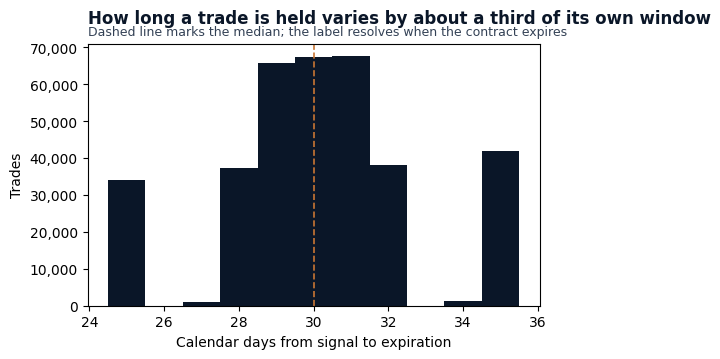

Settlement: 25-35 calendar days, 16-24 sessions of exposure, median 20


In [8]:
expiry_bar = calendar.select(pl.col("timestamp").alias("expiration"), pl.col("_bar").alias("_e"))
panel = panel.join(expiry_bar, on="expiration", how="left").with_columns(
    (pl.col("_e") - pl.col("_bar") - 1).alias("window")
)
resolution = panel.drop_nulls(PRIMARY_LABEL)
PRIMARY_WINDOW = int(resolution["window"].median())
LONGEST_WINDOW = int(resolution["window"].max())

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.hist(resolution["dte_calendar"].to_numpy(), bins=np.arange(24.5, 36.5, 1), color=COLORS["blue"])
ax.axvline(resolution["dte_calendar"].median(), color=COLORS["copper"], linestyle="--", lw=1.2)
ax.set_xlabel("Calendar days from signal to expiration")
ax.set_ylabel("Trades")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
add_message_title(
    ax,
    "How long a trade is held varies by about a third of its own window",
    subtitle="Dashed line marks the median; the label resolves when the contract expires",
)
show_with_alt(fig, "Histogram of calendar days between the signal date and expiration.")

print(
    f"Settlement: {resolution['dte_calendar'].min()}-{resolution['dte_calendar'].max()} calendar days, "
    f"{resolution['window'].min()}-{LONGEST_WINDOW} sessions of exposure, "
    f"median {PRIMARY_WINDOW}"
)

## D. Window validity

A join always returns something; the question is whether what it returns is the quantity
the label claims. Each property below fails silently and leaves plausible numbers behind,
so each is asserted rather than described.

The second assertion is a full reconciliation rather than a bound. Every row carrying no
label is attributed to exactly one cause - no premium quoted at entry, an exit session
past the end of the panel, no quote for the held contract on the exit date, a hedge path
the contract was not quoted on every day of, an expiration past the end of the underlying
panel, or an expiration on which the underlying itself did not trade - and the counts have
to sum to the height of the frame. A label built from a stale exit, or one that had
silently taken its exit price from a neighbouring contract, would break that identity.

The third assertion is what ties the recorded exit dates to the declared horizons. The
round-trip builder writes each exit date into the artifact, so the notebook can check it
rather than trust it: shifting the panel calendar by the horizon has to land on the same
session, both have to be missing together where the panel runs out, and the whole window
has to close on or before the contract expires.

In [9]:
NO_PREMIUM = pl.col("entry_straddle_mid").is_null()
CAUSES = {
    PRIMARY_LABEL: {
        "no entry premium": NO_PREMIUM,
        "expiry past the underlying panel": pl.col("expiration") > underlying["timestamp"].max(),
        "no underlying close at expiry": pl.col("_close_at_expiry").is_null(),
    }
} | {
    name: {
        "no entry premium": NO_PREMIUM,
        "exit session past the end of the panel": END_OF[name].is_null(),
        "no quote at exit": pl.col(f"exit_straddle_mid_{HORIZONS[name]}d").is_null(),
    }
    | (
        {"incomplete hedge path": pl.col(f"hedge_days_{HORIZONS[name]}d") != HORIZONS[name]}
        if "_dh_" in name
        else {}
    )
    for name in VARIANT_LABELS
}
for name, causes in CAUSES.items():
    # 1. An incomplete window is null, never a value.
    unlabelled = panel.filter(pl.any_horizontal(*causes.values()))
    assert unlabelled[name].null_count() == unlabelled.height, name

    # 2. Labelled rows plus the causes, each counted once, account for every row.
    seen, counts = pl.lit(False), {}
    for cause, cond in causes.items():
        counts[cause] = panel.filter(cond & ~seen).height
        seen = seen | cond
    assert panel.drop_nulls(name).height + sum(counts.values()) == panel.height, (name, counts)

    # 3. Each recorded exit lands where the declared horizon says, inside the contract.
    #    ne_missing rather than !=, so a pair of nulls counts as agreement and a null on
    #    one side only counts as a mismatch instead of dropping out of the comparison.
    if name in HORIZONS:
        exit_date = pl.col(f"exit_{HORIZONS[name]}d_date")
        assert panel.filter(exit_date.ne_missing(END_OF[name])).height == 0, name
    assert panel.filter(END_OF[name] > pl.col("expiration")).height == 0, name

    # 4. No discrete label is derived from a null return - vacuous by dtype here, since
    #    this notebook writes continuous labels only.
    assert panel.schema[name] == pl.Float64, name

    unlabelled = ", ".join(f"{n:,} {c}" for c, n in counts.items())
    print(f"{name}: {panel.drop_nulls(name).height:,} labelled; unlabelled {unlabelled}")

ret_to_expiry: 354,473 labelled; unlabelled 429 no entry premium, 5,081 expiry past the underlying panel, 854 no underlying close at expiry
fwd_ret_5d: 354,113 labelled; unlabelled 429 no entry premium, 1,418 exit session past the end of the panel, 4,877 no quote at exit
fwd_ret_10d: 333,102 labelled; unlabelled 429 no entry premium, 3,354 exit session past the end of the panel, 23,952 no quote at exit
fwd_ret_dh_5d: 351,865 labelled; unlabelled 429 no entry premium, 1,418 exit session past the end of the panel, 4,877 no quote at exit, 2,248 incomplete hedge path
fwd_ret_dh_10d: 323,847 labelled; unlabelled 429 no entry premium, 3,354 exit session past the end of the panel, 23,952 no quote at exit, 9,255 incomplete hedge path


Position zero below is the panel's last session. Every label has to fall to zero over its
own closing window and sit flat before it, and a scalar count of valid rows shows neither
failure this catches: a tail fabricated instead of nulled, which would sit flat all the way
to zero, and a short label stopped where a longer one runs out, which would put two
horizons on the same cliff. Each label here falls at its own depth. The primary label
recovers much deeper in than the others because it needs an expiration the underlying
panel still covers, which is about a month rather than the ten sessions the longest
fixed-horizon exit needs. The figure reads only whether a label is null and never its
value, so it is drawn over the whole panel including the holdout.

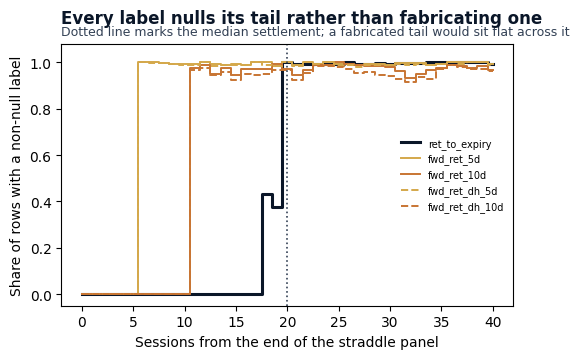

In [10]:
profile = (
    calendar.select("timestamp", "from_end")
    .join(panel.select("timestamp", *LABEL_NAMES), on="timestamp", how="left")
    .filter(pl.col("from_end") <= 40)
    .group_by("from_end")
    .agg([pl.col(name).is_not_null().mean().alias(name) for name in LABEL_NAMES])
    .sort("from_end")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in LABEL_NAMES:
    ax.plot(profile["from_end"], profile[name], ds="steps-mid", label=name, **STYLES[name])
ax.axvline(PRIMARY_WINDOW, color=COLORS["neutral"], linestyle=":", lw=1.2)
ax.set_xlabel("Sessions from the end of the straddle panel")
ax.set_ylabel("Share of rows with a non-null label")
ax.set_ylim(-0.05, 1.08)
add_message_title(
    ax,
    "Every label nulls its tail rather than fabricating one",
    subtitle="Dotted line marks the median settlement; a fabricated tail would sit flat across it",
)
ax.legend(loc="center right", frameon=False, fontsize=7)
show_with_alt(fig, "Non-null label rate by session position from the end of the straddle panel.")

## E. Distribution and base rate

What scale is the label, and does it mean the same thing across names and across regimes?
Everything from here through Section G is computed on the development period only, cut on
the date each trade **settles** rather than the date its signal is observed. A straddle
sold in the first week of December expires in January, so the two dates fall on opposite
sides of the boundary, and a cut on the signal date keeps rows whose outcome the holdout's
own prices decided. The label files themselves keep every row: what is excluded here is
what this notebook looks at, not what it writes.

In [11]:
dev = {
    name: panel.with_columns(END_OF[name].alias("_label_end"))
    .drop_nulls(name)
    .filter(pl.col("_label_end") < HOLDOUT_START)
    for name in LABEL_NAMES
}
for name, frame in dev.items():
    print(f"{name}: {frame.height:,} development rows through {frame['timestamp'].max()}")

ret_to_expiry: 282,470 development rows through 2020-12-04
fwd_ret_5d: 283,065 development rows through 2020-12-22
fwd_ret_10d: 263,863 development rows through 2020-12-15
fwd_ret_dh_5d: 281,047 development rows through 2020-12-22
fwd_ret_dh_10d: 255,773 development rows through 2020-12-15


All five labels go on one axis with identical bins and a logarithmic count axis. The claim
is about shape rather than width: closing the trade early truncates the distribution on
both sides, and hedging the direction away pulls the body in without moving the centre,
while carrying to expiration keeps a loss tail several times the premium collected. The
axis is narrower than the primary label's range, so rows outside it are counted below
rather than drawn.

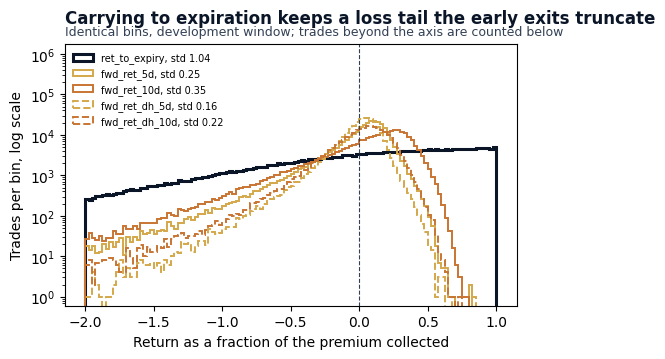

ret_to_expiry: mean -0.0487, std 1.0369, share positive 58.5%, 9,156 beyond the axis
fwd_ret_5d: mean +0.0044, std 0.2507, share positive 64.8%, 246 beyond the axis
fwd_ret_10d: mean +0.0552, std 0.3547, share positive 68.7%, 493 beyond the axis
fwd_ret_dh_5d: mean +0.0003, std 0.1643, share positive 59.6%, 37 beyond the axis
fwd_ret_dh_10d: mean +0.0159, std 0.2182, share positive 61.4%, 109 beyond the axis


In [12]:
bins = np.linspace(-2.0, 1.0, 121)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for name in LABEL_NAMES:
    series = dev[name][name]
    label = f"{name}, std {series.std():.2f}"
    ax.hist(series.to_numpy(), bins=bins, histtype="step", label=label, **STYLES[name])
ax.axvline(0, color=COLORS["neutral"], linestyle="--", lw=0.8)
ax.set_yscale("log")
ax.set_ylim(top=ax.get_ylim()[1] * 40)
ax.set_xlabel("Return as a fraction of the premium collected")
ax.set_ylabel("Trades per bin, log scale")
add_message_title(
    ax,
    "Carrying to expiration keeps a loss tail the early exits truncate",
    subtitle="Identical bins, development window; trades beyond the axis are counted below",
)
ax.legend(loc="upper left", frameon=False, fontsize=7)
show_with_alt(fig, "Histograms of all five labels on identical bins and a log count axis.")

for name, frame in dev.items():
    beyond = frame.filter(~pl.col(name).is_between(bins[0], bins[-1])).height
    print(
        f"{name}: mean {frame[name].mean():+.4f}, std {frame[name].std():.4f}, "
        f"share positive {(frame[name] > 0).mean():.1%}, {beyond:,} beyond the axis"
    )

Chapter 7.2 asks for the base rate to be tracked through time. For a continuous label
ranked across a cross-section, the quantity that has to be stable is the spread the model
ranks within: where it is not, the same rank correlation buys a different amount of
return. The spread is taken across names on each session first and only then averaged over
the year. Pooling every name-session in a year into one standard deviation instead adds
the movement of the panel's own mean from session to session to the spread across names on
a session, and a ranking model is scored on the second alone.

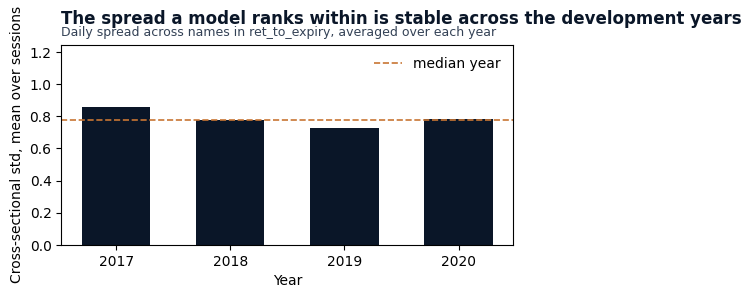

shape: (4, 3)
┌──────┬────────────┬───────┐
│ year ┆ dispersion ┆ names │
│ ---  ┆ ---        ┆ ---   │
│ i32  ┆ f64        ┆ f64   │
╞══════╪════════════╪═══════╡
│ 2017 ┆ 0.861      ┆ 211.0 │
│ 2018 ┆ 0.776      ┆ 248.0 │
│ 2019 ┆ 0.727      ┆ 251.0 │
│ 2020 ┆ 0.783      ┆ 224.0 │
└──────┴────────────┴───────┘


In [13]:
annual = (
    dev[PRIMARY_LABEL]
    .group_by("timestamp")
    .agg(pl.col(PRIMARY_LABEL).std().alias("dispersion"), pl.len().alias("names"))
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("dispersion").mean(), pl.col("names").median())
    .sort("year")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(annual["year"], annual["dispersion"], color=COLORS["blue"], width=0.6)
ax.axhline(
    annual["dispersion"].median(),
    color=COLORS["copper"],
    linestyle="--",
    lw=1.2,
    label="median year",
)
ax.set_xticks(annual["year"].to_list())
ax.set_ylim(0, annual["dispersion"].max() * 1.45)
ax.set_xlabel("Year")
ax.set_ylabel("Cross-sectional std, mean over sessions")
add_message_title(
    ax,
    "The spread a model ranks within is stable across the development years",
    subtitle=f"Daily spread across names in {PRIMARY_LABEL}, averaged over each year",
)
ax.legend(loc="upper right", frameon=False)
show_with_alt(fig, "Annual mean of the daily cross-sectional dispersion of the primary label.")

print(annual.with_columns(pl.col("dispersion").round(3)))

On the development window the hold-to-expiry label has a mean of -0.0487 of the premium
collected against a standard deviation of 1.0369, while 58.5% of trades end profitable:
most positions expire worth keeping and the ones that do not are several times the size of
the ones that do. Closing at ten sessions instead leaves a mean of +0.0552 on a standard
deviation of 0.3547, and hedging that trade's direction away cuts the standard deviation
to 0.2182 while moving the mean to +0.0159 - the hedge takes out the moves in both
directions. Cross-sectional dispersion is steady across the development years, running from
0.727 in the quietest to 0.861 in the loudest.

## F. Overlap and effective sample size

Sampling a month-long trade at every session makes consecutive rows share almost all of
their holding window, so the row count overstates the evidence. Two measurements answer
that in different units: how fast the overlap decays, and what the rows are worth once it
is priced in. `effective_sample_size` applies Chapter 7.2's average-uniqueness weighting
per name, because concurrency is a property of one name's own overlapping trades.

Both are counted on the panel session calendar the windows were built on, not on the rows
each label happens to have. A name is quoted on roughly half the sessions here, and closing
over the gaps would pair trades that share nothing and report the overlap as larger than it
is.

The weighting behind the second measurement is worth stating, because it is what the count
means. A trade exposed for $h$ sessions consumes the $h$ returns realised over them, and
the trade opened one session later shares $h-1$ of those, so on a grid with no gaps the
average share of a trade's own window that nothing else spans converges to $1/h$. The
primary label is weighted by each trade's own exposure rather than by the median, because a
median window prices the overlap of a trade none of these rows is.

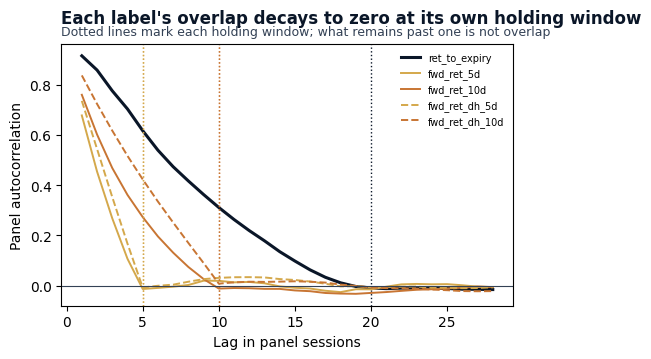

ret_to_expiry: N=282,470, N_eff=22,897, ratio 0.0811 against 0.0500 for windows of 20 sessions overlapping fully; autocorrelation 0.915 at lag one, -0.009 at that lag


fwd_ret_5d: N=283,065, N_eff=69,719, ratio 0.2463 against 0.2000 for windows of 5 sessions overlapping fully; autocorrelation 0.678 at lag one, -0.014 at that lag


fwd_ret_10d: N=263,863, N_eff=39,747, ratio 0.1506 against 0.1000 for windows of 10 sessions overlapping fully; autocorrelation 0.760 at lag one, -0.012 at that lag


fwd_ret_dh_5d: N=281,047, N_eff=69,392, ratio 0.2469 against 0.2000 for windows of 5 sessions overlapping fully; autocorrelation 0.736 at lag one, -0.008 at that lag


fwd_ret_dh_10d: N=255,773, N_eff=39,084, ratio 0.1528 against 0.1000 for windows of 10 sessions overlapping fully; autocorrelation 0.837 at lag one, 0.008 at that lag


In [14]:
max_lag = LONGEST_WINDOW + 4
acf = {
    name: panel_autocorrelation(dev[name], name, max_lag=max_lag, bar_col="_bar")
    for name in LABEL_NAMES
}

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
lags = np.arange(1, max_lag + 1)
for name in LABEL_NAMES:
    window = PRIMARY_WINDOW if name == PRIMARY_LABEL else HORIZONS[name]
    ax.plot(lags, acf[name], label=name, **STYLES[name])
    ax.axvline(window, color=STYLES[name]["color"], linestyle=":", lw=1.0)
ax.axhline(0, color=COLORS["neutral"], lw=0.8)
ax.set_xlabel("Lag in panel sessions")
ax.set_ylabel("Panel autocorrelation")
add_message_title(
    ax,
    "Each label's overlap decays to zero at its own holding window",
    subtitle="Dotted lines mark each holding window; what remains past one is not overlap",
)
ax.legend(loc="upper right", frameon=False, fontsize=7)
show_with_alt(fig, "Panel autocorrelation of all five labels against lag in panel sessions.")

for name in LABEL_NAMES:
    window = PRIMARY_WINDOW if name == PRIMARY_LABEL else HORIZONS[name]
    per_row = {"horizon_col": "window"} if name == PRIMARY_LABEL else {"horizon": window}
    n_rows, n_eff = effective_sample_size(dev[name], bar_col="_bar", **per_row)
    print(
        f"{name}: N={n_rows:,}, N_eff={n_eff:,.0f}, ratio {n_eff / n_rows:.4f} against "
        f"{1 / window:.4f} for windows of {window} sessions overlapping fully; "
        f"autocorrelation {acf[name][0]:.3f} at lag one, {acf[name][window - 1]:.3f} at that lag"
    )

The primary label's 282,470 development rows carry 22,897 effective observations, a ratio
of 0.0811 against the 0.0500 a fully overlapped 20-session window implies, weighting each
trade by its own exposure rather than by the median. The gap is the panel's own sparsity
rather than a shorter window: a name quoted on half the sessions has fewer concurrent
trades open than a dense grid would give it, and the shorter labels sit above their own
reference values for the same reason - 0.2463 against 0.2000 at five sessions.
Autocorrelation falls from 0.915 at lag one to -0.009 at the median window, so a purge
shorter than the exposure would leave training and validation sharing an outcome. That gap
is set by the window itself, not by these counts.

## G. Baseline floor

One signal against the primary label on the development period, with no feature
engineering: the variance risk premium the hypothesis names, computed as the difference
between the at-the-money implied volatility quoted on the signal date and the volatility
the underlying realised over the previous month. Measuring what one obvious signal earns
before building any features is what makes a later improvement meaningful.

Two things decide whether the realised half of that difference is the quantity its name
claims. It is measured on split-adjusted closes, and only within a stretch over which the
ticker refers to one and the same company - the dataset numbers those stretches in
`sec_id` - so that a merger or a spin-off resetting the adjustment factor cannot
masquerade as a market move. And
it is measured on the market session calendar rather than on each name's own quoted rows:
a stock suspended for a month has two rows either side of the absence, and a window closed
over those rows is not the number of sessions it is named for. Each identity segment is
laid onto the sessions the market was open for between its first and last row, and a
window that spans a session the stock did not trade on yields no value at all.

The information coefficient is the cross-sectional rank correlation on each session,
averaged over sessions, which is the quantity a ranking model is scored on; pooling every
name-session instead mixes a cross-sectional claim with a time-series one. The library call
returns its series ordered by time, which the standard error depends on. The minimum
cross-section is half the median rather than a bare count, so it means the same thing on a
universe of another size.

The standard error corrects for autocorrelation, using the Newey-West estimator: it widens
the error bar by however much neighbouring observations repeat each other, instead of
treating each one as fresh evidence. That correction is necessary here because the IC
series inherits the label's overlap, and a month of consecutive sessions is scoring largely
the same trades. Its bandwidth - how many neighbouring sessions it looks across - is set
from the longest window any trade runs for, so it covers every overlap the series carries
rather than half of them.

The session grid is built once, per security identity, and spans each segment's own first
and last quoted session so that a name is not given rows before it listed or after it left.

In [15]:
dense = (
    underlying.group_by(["symbol", "sec_id"])
    .agg(pl.col("timestamp").min().alias("_first"), pl.col("timestamp").max().alias("_last"))
    .join(underlying.select("timestamp").unique(), how="cross")
    .filter(pl.col("timestamp").is_between(pl.col("_first"), pl.col("_last")))
    .select("symbol", "sec_id", "timestamp")
    .join(underlying, on=["symbol", "sec_id", "timestamp"], how="left")
)
print(
    f"{underlying.height:,} quoted rows over {dense.height:,} sessions the names were listed "
    f"for: {dense.height - underlying.height:,} sessions a listed name did not trade on"
)

635,703 quoted rows over 635,727 sessions the names were listed for: 24 sessions a listed name did not trade on


In [16]:
RV_COL = f"rv_{RV_WINDOW}d"
annualised_rv = pl.col("clean_log_return").rolling_std(RV_WINDOW).over(["symbol", "sec_id"])
realised = (
    reconcile_underlying_log_returns(dense)
    .sort(["symbol", "sec_id", "timestamp"])
    .with_columns((annualised_rv * np.sqrt(SESSIONS_PER_YEAR)).alias(RV_COL))
)
baseline = (
    straddles.select(["timestamp", "symbol", "iv_atm"])
    .join(realised.select(["timestamp", "symbol", RV_COL]).drop_nulls(), on=["timestamp", "symbol"])
    .with_columns((pl.col("iv_atm") - pl.col(RV_COL)).alias("vrp_proxy"))
    .join(
        dev[PRIMARY_LABEL].select(["timestamp", "symbol", PRIMARY_LABEL]),
        on=["timestamp", "symbol"],
    )
    .drop_nulls(["vrp_proxy", PRIMARY_LABEL])
)
median_cross_section = int(baseline.group_by("timestamp").len()["len"].median())
min_obs = median_cross_section // 2

ic = cross_sectional_ic_series(
    baseline,
    baseline,
    pred_col="vrp_proxy",
    ret_col=PRIMARY_LABEL,
    date_col="timestamp",
    entity_col="symbol",
    min_obs=min_obs,
).sort("timestamp")  # HAC autocovariances are meaningless over a permutation of time
stats = compute_ic_hac_stats(ic, ic_col="ic", label_horizon=LONGEST_WINDOW)

print(
    f"Baseline: implied minus realised volatility against {PRIMARY_LABEL}, {baseline.height:,} rows"
)
print(f"  median cross-section {median_cross_section} names, minimum {min_obs}")
print(f"  sessions scored {stats['n_periods']:,}, mean IC {stats['mean_ic']:.4f}")
print(
    f"  HAC t {stats['t_stat']:.2f} on {stats['effective_lags']} Bartlett lags, "
    f"naive t {stats['naive_t_stat']:.2f}, p {stats['p_value']:.3g}"
)

Baseline: implied minus realised volatility against ret_to_expiry, 276,005 rows
  median cross-section 246 names, minimum 123
  sessions scored 950, mean IC -0.0100
  HAC t -1.06 on 23 Bartlett lags, naive t -3.21, p 0.291


The variance risk premium earns a mean information coefficient of -0.0100 against the
hold-to-expiry label over 950 scored sessions on a cross-section of at least 123 names.
The sign is the opposite of what the hypothesis implies: names whose options are priced
furthest above their recent realised volatility are, if anything, the ones whose short
straddles pay least. Under the naive standard error that is a t-statistic of -3.21, which
the Newey-West rule on 23 Bartlett lags reduces to -1.06 with a p-value of 0.291 - the
whole apparent significance was the overlap being counted as evidence. The floor a feature
has to clear is a mean IC of -0.0100 the data cannot separate from zero.

## H. Artifacts and the audit record

Every label file gets a small JSON file written beside it. It answers the question a
reader has months later, looking at a parquet file and a model trained on it: is this the
same data the model saw? A short hash of the values in the file answers that directly, and
the rest of the file says what was hashed and where it came from - the number of rows, the
columns that identify a row, the notebook that wrote it, and the hashes of the frames it
was built from. Without that last part a re-run against a refreshed download of the option
chain is indistinguishable from a re-run against the same one.

A row is identified by the date, the name, and which option structure on that name -
`instrument_id` - because a symbol can carry more than one, and all three are needed to
join a label to the features built for the same position.

The folds that train models are derived per label by `case_studies/utils/cv_window.py`
from `config/setup.yaml` and the timeline of the label parquet written here, so which rows
land in these files is what sets where the fold boundaries fall.

In [17]:
KEYS = ["timestamp", "symbol", "instrument_id"]
for name in LABEL_NAMES:
    extra = {"market_data": MARKET_DATA_DIGEST} if name == PRIMARY_LABEL else {}
    inputs = {"contract_returns": CONTRACT_DIGEST} | (
        {"hedge_path": HEDGE_DIGEST} if "_dh_" in name else extra
    )
    # The primary label carries its own settlement date: the notebooks that model it
    # derive each row's label endpoint from it rather than from a fixed horizon.
    columns = [name, "dte_calendar"] if name == PRIMARY_LABEL else [name]
    record = write_artifact(
        panel.drop_nulls(name).select(
            "timestamp", "symbol", pl.lit(INSTRUMENT_ID).alias("instrument_id"), *columns
        ),
        LABELS_DIR / f"{name}.parquet",
        keys=KEYS,
        written_by="02_labels",
        inputs=inputs,
    )
    print(f"{name}.parquet: {record['n_rows']:,} rows, digest {record['digest']}")

ret_to_expiry.parquet: 354,473 rows, digest f1d926ba6f09f8c8
fwd_ret_5d.parquet: 354,113 rows, digest a1a25bd0526e8909
fwd_ret_10d.parquet: 333,102 rows, digest 6414058873427591
fwd_ret_dh_5d.parquet: 351,865 rows, digest 6e6799f163225be5
fwd_ret_dh_10d.parquet: 323,847 rows, digest bbc38febd1f2e6f3


The record Chapter 7.2 requires to close a label definition, one row per label, built from
the values computed above rather than written by hand. The buffer and the outcome horizon
are separate rows because they are separate numbers here: the buffer is declared in
calendar days and has to cover the longest settlement, while the outcome horizon is what
the label's overlap is measured in.

In [18]:
READERS = {
    PRIMARY_LABEL: "04_model_based_features.py, 05_evaluation.py, and every model and "
    "backtest stage through the shared loaders, as labels.primary",
    "fwd_ret_10d": "90_ic_diagnostic.py",
    "fwd_ret_dh_10d": "05_evaluation.py and 90_ic_diagnostic.py",
}
print(f"\nLabel audit record - cross-validation buffer {LABEL_BUFFER} for every label")
for name in LABEL_NAMES:
    primary, frame = name == PRIMARY_LABEL, dev[name]
    window = PRIMARY_WINDOW if primary else HORIZONS[name]
    exit_leg = "cash settlement at intrinsic value" if primary else "mid of the same contract"
    when = (
        f"variable: {resolution['window'].min()}-{LONGEST_WINDOW} sessions of exposure"
        if primary
        else f"fixed at {window} sessions from entry"
    )
    print(
        f"\n{name}\n  anchor       mid of the straddle sold one session after the signal"
        f"\n  exit         {exit_leg}"
        f"\n  horizon      {window} sessions{' (median)' if primary else ''}"
        f"\n  resolution   {when}"
        f"\n  overlap      {window - 1} sessions shared by consecutive trades in one name"
        f"\n  base rate    mean {frame[name].mean():+.5f}, share positive {(frame[name] > 0).mean():.3f}"
        f"\n  consumed by  {READERS.get(name, 'nothing downstream; written for comparison here')}"
    )


Label audit record - cross-validation buffer 35D for every label

ret_to_expiry
  anchor       mid of the straddle sold one session after the signal
  exit         cash settlement at intrinsic value
  horizon      20 sessions (median)
  resolution   variable: 16-24 sessions of exposure
  overlap      19 sessions shared by consecutive trades in one name
  base rate    mean -0.04873, share positive 0.585
  consumed by  04_model_based_features.py, 05_evaluation.py, and every model and backtest stage through the shared loaders, as labels.primary

fwd_ret_5d
  anchor       mid of the straddle sold one session after the signal
  exit         mid of the same contract
  horizon      5 sessions
  resolution   fixed at 5 sessions from entry
  overlap      4 sessions shared by consecutive trades in one name
  base rate    mean +0.00436, share positive 0.648
  consumed by  nothing downstream; written for comparison here

fwd_ret_10d
  anchor       mid of the straddle sold one session after the si

## Key takeaways

1. **On an option panel, a forward return is a round trip in one contract, not a shift of
   a price column.** The 30-day at-the-money row is a different instrument every session,
   so a shifted difference reports the change of contract as profit. Look the held
   contract up in the raw chain instead.
2. **Reconcile every unlabelled row to one cause.** A missing quote at exit, a premium
   that was never quoted, a hedge path with a hole in it and an expiration past the end
   of the price panel all fail without raising, and a reconciliation that has to balance
   catches what a row count passed over does not.
3. **Exclude the holdout on the date the position settles.** When the settlement date is
   written into the contract rather than fixed at a number of sessions, that date is the
   boundary - a trade opened before the holdout and expiring inside it is a holdout trade.
4. **A row count overstates the evidence when holding windows overlap.** The effective
   count says by how much in rows, and the same overlap priced into a standard error is
   what turns a t-statistic that reads as decisive into one that cannot be separated from
   zero.
5. **Check the sign of a baseline before assuming its size is the question.** The variance
   risk premium points the opposite way to the hypothesis on this universe, which is a
   fact about the cross-section that a mean-level argument about the premium would miss.

**Known limitations.** Mid-to-mid pricing is not what a trader receives; the entry
half-spread and the commission are swept in `14_costs.py`, and the primary label avoids
the exit half-spread only because cash settlement needs no closing trade. The delta hedge
is rebalanced at the close and charges nothing for doing so. The universe is every name
with a quoted matched-strike straddle, with the liquidity screen applied downstream rather
than here. The baseline is one signal, on one month of realised volatility.

**Next**: `03_financial_features.py` builds the volatility-surface, term-structure and
instrument-state features on the same panel; `05_evaluation.py` is where those features
are first measured against the labels written here.